In [6]:
import os
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
import numpy as np

In [7]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### LOAD DATA

In [8]:
image_transform=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]), 
])

dataset=datasets.ImageFolder(root="dataset/",transform=image_transform)
print(len(dataset)) 
print(dataset.classes)
num_classes=len(dataset.classes)
num_classes
train_size=int(len(dataset)*0.75) 
val_size=len(dataset)-train_size

train_size,val_size

2301
['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']


(1725, 576)

In [9]:
print(dataset.class_to_idx)

{'F_Breakage': 0, 'F_Crushed': 1, 'F_Normal': 2, 'R_Breakage': 3, 'R_Crushed': 4, 'R_Normal': 5}


In [10]:
train_dataset,val_dataset=random_split(dataset,[train_size,val_size])

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)

for images,labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.535425].


torch.Size([3, 224, 224])


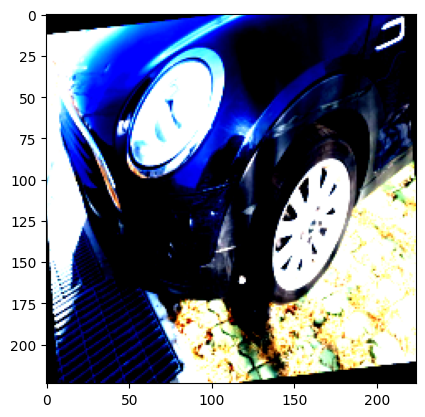

In [11]:
print(images[0].shape)
images[0].permute(1,2,0).shape
plt.imshow(images[0].permute(1,2,0))
plt.show()

### MODEL-1 CNN

In [12]:
class carclassifierCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network=nn.Sequential(
        nn.Conv2d(in_channels=3,out_channels=16,kernel_size=(3,3),stride=1,padding=1), #output(16,224*224)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)), #output (16,112*112)

        nn.Conv2d(in_channels=16,out_channels=32,kernel_size=(3,3),stride=1,padding=1), #output(32,112*112)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)),#output (32,56*56)

        nn.Conv2d(in_channels=32,out_channels=64,kernel_size=(3,3),stride=1,padding=1), #output(64,56*56)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)),#output (64,28*28)

        nn.Flatten(),
        nn.Linear(64*28*28,512),
        nn.ReLU(),
        nn.Linear(512,num_classes)
        )
    def forward(self,x):
        x=self.network(x)
        return x

In [13]:
model=carclassifierCNN(num_classes=num_classes).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [14]:
values,indices=torch.max(torch.tensor([[10,2,2,6,85,12]]),dim=1)
values,indices

(tensor([85]), tensor([4]))

In [16]:
def train_model(model,criterion,optimizer,epochs=5):
    start=time.time()
    for epoch in range(epochs):
        model.train()
        running_loss=0.0
        for batch_num,(images,labels) in enumerate(train_loader):
            images,labels=images.to(device),labels.to(device)
            optimizer.zero_grad()
            outputs=model(images)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            if (batch_num+1)%10==0:
                print(f"Batch:{batch_num+1}, Epoch:{epoch+1} ,loss:{loss.item():.2f}")
            
            running_loss+=loss.item()*images.size(0) # total loss of an entire batch
        epoch_loss=running_loss/len(train_loader.dataset)
        print(f"epoch [{epoch+1}/{epochs}], Avg loss:{epoch_loss:.4f}")

        model.eval()
        correct=0
        total=0
        all_labels=[]
        all_predicted=[]
        with torch.no_grad():
            for images,labels in val_loader:
                images,labels=images.to(device),labels.to(device)
                outputs=model(images)
                _,predicted=torch.max(outputs.data,1)
                total+=labels.size(0)
                correct+=(predicted==labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predicted.extend(predicted.cpu().numpy())
            accuracy=(correct/total)*100
            print(f"Validation Accuracy: {accuracy:.2f} ")
    end=time.time()
    print(f"Execution time :{end-start} seconds")
    return all_labels,all_predicted

In [34]:
all_labels,all_predictions=train_model(model,criterion,optimizer,epochs=5)

KeyboardInterrupt: 

### MODEL-1 CNN WITH REGULARIZATION

In [15]:
class carclassifierCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network=nn.Sequential(
        nn.Conv2d(in_channels=3,out_channels=16,kernel_size=(3,3),stride=1,padding=1), #output(16,224*224)
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)), #output (16,112*112)

        nn.Conv2d(in_channels=16,out_channels=32,kernel_size=(3,3),stride=1,padding=1), #output(32,112*112)
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)),#output (32,56*56)

        nn.Conv2d(in_channels=32,out_channels=64,kernel_size=(3,3),stride=1,padding=1), #output(64,56*56)
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)),#output (64,28*28)

        nn.Flatten(),
        nn.Linear(64*28*28,512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512,num_classes)
        )
    def forward(self,x):
        x=self.network(x)
        return x

In [16]:
model=carclassifierCNN(num_classes=num_classes).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4)

In [17]:
all_labels,all_predictions=train_model(model,criterion,optimizer,epochs=5)

Batch:10, Epoch:1 ,loss:15.94
Batch:20, Epoch:1 ,loss:3.56
Batch:30, Epoch:1 ,loss:2.03
Batch:40, Epoch:1 ,loss:1.44
Batch:50, Epoch:1 ,loss:1.20
epoch [1/5], Avg loss:7.1175
Validation Accuracy: 45.14 
Batch:10, Epoch:2 ,loss:1.55
Batch:20, Epoch:2 ,loss:1.41
Batch:30, Epoch:2 ,loss:1.51
Batch:40, Epoch:2 ,loss:1.35
Batch:50, Epoch:2 ,loss:1.36
epoch [2/5], Avg loss:1.3218
Validation Accuracy: 53.12 
Batch:10, Epoch:3 ,loss:1.60
Batch:20, Epoch:3 ,loss:0.83
Batch:30, Epoch:3 ,loss:1.11
Batch:40, Epoch:3 ,loss:1.19
Batch:50, Epoch:3 ,loss:1.13
epoch [3/5], Avg loss:1.2447
Validation Accuracy: 51.04 
Batch:10, Epoch:4 ,loss:1.20
Batch:20, Epoch:4 ,loss:1.10
Batch:30, Epoch:4 ,loss:1.13
Batch:40, Epoch:4 ,loss:1.34
Batch:50, Epoch:4 ,loss:1.33
epoch [4/5], Avg loss:1.1695
Validation Accuracy: 50.52 
Batch:10, Epoch:5 ,loss:1.36
Batch:20, Epoch:5 ,loss:0.97
Batch:30, Epoch:5 ,loss:1.11
Batch:40, Epoch:5 ,loss:1.31
Batch:50, Epoch:5 ,loss:1.01
epoch [5/5], Avg loss:1.1656
Validation Accura

### Transfer Learning

In [ ]:
model=models.efficientnet_b0(weights="DEFAULT")
#print(model)
print(model.classifier[1])
model.classifier[1].in_features

In [ ]:
class carclassifierefficientnet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.model=models.efficientnet_b0(weights="DEFAULT")
        for param in self.model.parameters(): 
            param.requires_grad=False
        in_features=self.model.classifier[1].in_features
        self.model.classifier=nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features,num_classes)
        )
    def forward(self,x):
        x=self.model(x)
        return x

In [ ]:
model=carclassifierefficientnet(num_classes=num_classes).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(filter(lambda p : p.requires_grad,model.parameters()),lr=0.001,weight_decay=1e-4)

In [ ]:
all_labels,all_predictions=train_model(model,criterion,optimizer,epochs=5)

In [ ]:
accuarcy just imporved slightly

### ResNet  model

In [25]:
class carclassifierresnet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.resnet50(weights="DEFAULT")
        # Freeze all layers
        for param in self.model.parameters():
            param.requires_grad = False
        # Unfreeze layer4
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        # Get input features of final layer
        in_features = self.model.fc.in_features
        # Replace fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [26]:
model=carclassifierresnet(num_classes=num_classes).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(filter(lambda p : p.requires_grad,model.parameters()),lr=0.001,weight_decay=1e-4)

In [ ]:
all_labels,all_predictions=train_model(model,criterion,optimizer,epochs=5)

### HYper parameter tuning

In [21]:
class carclassifierresnet(nn.Module):
    def __init__(self, num_classes,dropout_rate):
        super().__init__()
        self.model = models.resnet50(weights="DEFAULT")
       
        for param in self.model.parameters():
            param.requires_grad = False
        
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        
        in_features = self.model.fc.in_features
        
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [22]:
model=carclassifierresnet(num_classes=num_classes,dropout_rate=0.2).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(filter(lambda p : p.requires_grad,model.parameters()),lr=0.005)
all_labels,all_predictions=train_model(model,criterion,optimizer,epochs=10)

Batch:10, Epoch:1 ,loss:1.17
Batch:20, Epoch:1 ,loss:0.92
Batch:30, Epoch:1 ,loss:0.85
Batch:40, Epoch:1 ,loss:0.87
Batch:50, Epoch:1 ,loss:0.58
epoch [1/10], Avg loss:0.8731
Validation Accuracy: 64.76 
Batch:10, Epoch:2 ,loss:0.35
Batch:20, Epoch:2 ,loss:0.36
Batch:30, Epoch:2 ,loss:0.46
Batch:40, Epoch:2 ,loss:0.33
Batch:50, Epoch:2 ,loss:0.47
epoch [2/10], Avg loss:0.5144
Validation Accuracy: 78.47 
Batch:10, Epoch:3 ,loss:0.28
Batch:20, Epoch:3 ,loss:0.40
Batch:30, Epoch:3 ,loss:0.26
Batch:40, Epoch:3 ,loss:0.53
Batch:50, Epoch:3 ,loss:0.45
epoch [3/10], Avg loss:0.3875
Validation Accuracy: 74.83 
Batch:10, Epoch:4 ,loss:0.31
Batch:20, Epoch:4 ,loss:0.37
Batch:30, Epoch:4 ,loss:0.13
Batch:40, Epoch:4 ,loss:0.37
Batch:50, Epoch:4 ,loss:0.36
epoch [4/10], Avg loss:0.2981
Validation Accuracy: 77.78 
Batch:10, Epoch:5 ,loss:0.19
Batch:20, Epoch:5 ,loss:0.25
Batch:30, Epoch:5 ,loss:0.14
Batch:40, Epoch:5 ,loss:0.12
Batch:50, Epoch:5 ,loss:0.31
epoch [5/10], Avg loss:0.2255
Validation Ac

### MODEL EVALUATION USING CONFUSION MATRIX AND CLASSIFICATION REPORT

In [23]:
report=classification_report(all_labels,all_predictions)
print(report)

              precision    recall  f1-score   support

           0       0.90      0.79      0.84       126
           1       0.69      0.75      0.72        88
           2       0.85      0.92      0.88       121
           3       0.84      0.71      0.77        79
           4       0.75      0.66      0.70        86
           5       0.70      0.89      0.79        76

    accuracy                           0.79       576
   macro avg       0.79      0.79      0.78       576
weighted avg       0.80      0.79      0.79       576



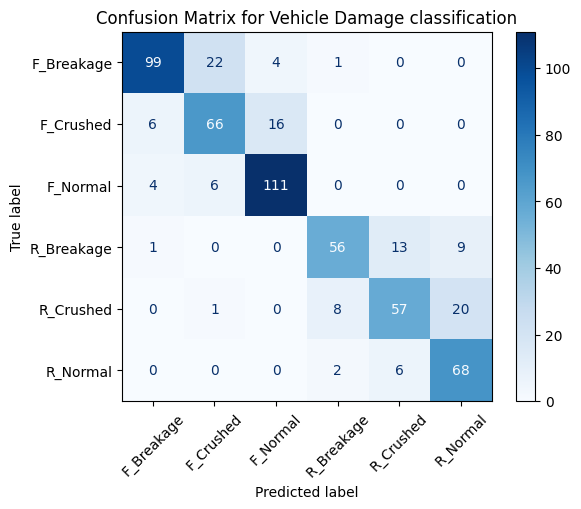

In [24]:
class_names=dataset.classes
cf=confusion_matrix(all_labels,all_predictions,labels=np.arange(num_classes))
disp=ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=class_names)
disp.plot(cmap=plt.cm.Blues,xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage classification")
plt.show()

In [ ]:
torch.save(model.state_dict(),"saved_model.pth")